In [ ]:
import numpy as np
import pandas as pd

df = pd.read_csv("../data/df_with_2regimes.csv", parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

columns_to_drop = ['p_sigma', 'p_r', 'p_d', 'regime', 'regime_id']
df_hmm = df.drop(columns=columns_to_drop, errors='ignore').copy()

# Rename target to target_vol
if 'target' in df_hmm.columns:
    df_hmm = df_hmm.rename(columns={"target": "target_vol"})

# Create next-day realized variance target
df_hmm["target_var"] = df_hmm["realized_variance"].shift(-1)

# Realized variance lag/rolling features
df_hmm["rvar_1"]  = df_hmm["realized_variance"]
df_hmm["rvar_2"]  = df_hmm["realized_variance"].rolling(window=2, min_periods=2).mean()
df_hmm["rvar_3"]  = df_hmm["realized_variance"].rolling(window=3, min_periods=3).mean()
df_hmm["rvar_7"]  = df_hmm["realized_variance"].rolling(window=7, min_periods=7).mean()
df_hmm["rvar_30"] = df_hmm["realized_variance"].rolling(window=30, min_periods=30).mean()

# Realized volatility lag/rolling features
df_hmm["rvol_1"]  = df_hmm["realized_volatility"]
df_hmm["rvol_2"]  = df_hmm["realized_volatility"].rolling(window=2, min_periods=2).mean()
df_hmm["rvol_3"]  = df_hmm["realized_volatility"].rolling(window=3, min_periods=3).mean()
df_hmm["rvol_7"]  = df_hmm["realized_volatility"].rolling(window=7, min_periods=7).mean()
df_hmm["rvol_30"] = df_hmm["realized_volatility"].rolling(window=30, min_periods=30).mean()

# HMM feature set for regime identification
features = ["log_return", "rvol_1", "rvol_7", "rvol_30"]

# Drop rows with NaN in HMM features only (keep all other columns)
df_hmm = df_hmm.dropna(subset=features).reset_index(drop=True)

# Sanity check
print("Dataset shape:", df_hmm.shape)
print("Columns:", df_hmm.columns.tolist())
print("\nRemaining NaNs in HMM features:")
print(df_hmm[features].isna().sum())
print("\nFirst 10 rows:")
print(df_hmm.head(10))

Dataset shape: (3489, 43)
Columns: ['date', 'log_return', 'realized_variance', 'realized_volatility', 'gtrend_pct_change', 'blockchain_diff_log_n_transactions', 'blockchain_diff_log_transaction_fee_usd', 'blockchain_diff_log_n_unique_addresses', 'blockchain_diff_log_transaction_volume_usd', 'log_volume', 'target_vol', 'gold_close_ret', 'silver_close_ret', 'brent_close_ret', 'dji_close_ret', 'spx_close_ret', 'rut_close_ret', 'nasdaq_close_ret', 'usdcny_close_ret', 'usdeur_close_ret', 'gold_volume_chg', 'silver_volume_chg', 'brent_volume_chg', 'dji_volume_chg', 'spx_volume_chg', 'rut_volume_chg', 'nasdaq_volume_chg', 'vix_close_chg', 'hash-rate_chg', 'difficulty_chg', 'median-confirmation-time_chg', 'blockchain_log_mempool_count_chg', 'target_var', 'rvar_1', 'rvar_2', 'rvar_3', 'rvar_7', 'rvar_30', 'rvol_1', 'rvol_2', 'rvol_3', 'rvol_7', 'rvol_30']

Remaining NaNs in HMM features:
log_return    0
rvol_1        0
rvol_7        0
rvol_30       0
dtype: int64

First 10 rows:
        date  l

In [38]:
train_window = 365 #1 year of trading days
n_obs = len(df_hmm)

# pre-allocate the regime label array with -1 (unassigned)
regime_labels = np.full(n_obs, -1, dtype=int)
prob_high_labels = np.full(n_obs, np.nan)

In [39]:
''' following HMM literature (Hashish (2019)), 
    1. standardise features
    2. fit a 2-state Gaussian HMM via Baum-Welch
    3. most probable state sequence via Viterbi
    4. relabel states consistently: 1 = high vol, 0 = low vol '''

from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler

def fit_hmm_and_decode(window_df):
    X = window_df[features].values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X) # standardise features

    
    model = GaussianHMM(
        n_components=2,
        covariance_type="diag",
        n_iter=1000,
        random_state=4211
    )
    model.fit(X_scaled)
    
    # Viterbi algorithm to decode the most likely sequence of hidden states
    raw_states = model.predict(X_scaled) 
    raw_probs = model.predict_proba(X_scaled) # shape: (365,2)

    # Relabel states consistently across windows based on mean realized volatility
    rv = window_df["realized_volatility"].values
    
    mean_rv_state0 = rv[raw_states == 0].mean()
    mean_rv_state1 = rv[raw_states == 1].mean()
    
    if mean_rv_state0 > mean_rv_state1:
        states = 1 - raw_states
        prob_high = raw_probs[:, 0]  # state 0 was high vol, so flip
    else:
        states = raw_states
        prob_high = raw_probs[:, 1]  # state 1 is already high vol

    return states, model, prob_high

In [40]:
# Rolling window HMM

import warnings
warnings.filterwarnings("ignore")  # suppress hmmlearn convergence warnings

for t in range(train_window, n_obs):
    window = df_hmm.iloc[t - train_window : t] # Slice training window: rows [t-train_window, t)
    states, model, prob_high = fit_hmm_and_decode(window)
    regime_labels[t - 1]    = states[-1]
    prob_high_labels[t - 1] = prob_high[-1]
    
    # Progress update every 500 steps
    if (t - train_window) % 500 == 0:
        pct = 100 * (t - train_window) / (n_obs - train_window)
        print(f"  {t - train_window}/{n_obs - train_window} windows ({pct:.1f}%)")

print("Rolling HMM completed.")

  0/3124 windows (0.0%)
  500/3124 windows (16.0%)
  1000/3124 windows (32.0%)
  1500/3124 windows (48.0%)
  2000/3124 windows (64.0%)
  2500/3124 windows (80.0%)
  3000/3124 windows (96.0%)
Rolling HMM completed.


In [41]:
# regime labelling
df_hmm["hmm_regime"] = regime_labels
df_hmm["hmm_prob_high"] = prob_high_labels

# counts before cleaning
labeled   = df_hmm[df_hmm["hmm_regime"] != -1]
n_high    = (labeled["hmm_regime"] == 1).sum()
n_low     = (labeled["hmm_regime"] == 0).sum()
n_nolabel = (df_hmm["hmm_regime"] == -1).sum()

print(f"High vol regime (1): {n_high}")
print(f"Low vol regime (0): {n_low}")
print(f"No Label (-1): {n_nolabel}")

# convert sentinel to missing for modelling
df_hmm["hmm_regime"] = df_hmm["hmm_regime"].replace(-1, np.nan)

# lag features
df_hmm["hmm_regime_lag1"] = df_hmm["hmm_regime"].shift(1)
df_hmm["hmm_prob_high_lag1"] = df_hmm["hmm_prob_high"].shift(1)
df_hmm["hmm_prob_high_lag2"] = df_hmm["hmm_prob_high"].shift(2)
df_hmm["hmm_prob_high_roll5"] = df_hmm["hmm_prob_high"].shift(1).rolling(5, min_periods=5).mean()

High vol regime (1): 1312
Low vol regime (0): 1812
No Label (-1): 365


In [42]:
df_hmm.to_csv("df_hmm.csv", index=False)
print(df_hmm[["date", "hmm_regime", "hmm_prob_high", "hmm_regime_lag1", 
          "hmm_prob_high_lag1", "hmm_prob_high_lag2", "hmm_prob_high_roll5"]].tail(10))

           date  hmm_regime  hmm_prob_high  hmm_regime_lag1  \
3479 2026-01-22         0.0       0.000003              0.0   
3480 2026-01-23         0.0       0.000005              0.0   
3481 2026-01-24         0.0       0.000131              0.0   
3482 2026-01-25         0.0       0.000005              0.0   
3483 2026-01-26         0.0       0.000007              0.0   
3484 2026-01-27         0.0       0.000018              0.0   
3485 2026-01-28         0.0       0.000005              0.0   
3486 2026-01-29         0.0       0.248739              0.0   
3487 2026-01-30         0.0       0.000426              0.0   
3488 2026-01-31         NaN            NaN              0.0   

      hmm_prob_high_lag1  hmm_prob_high_lag2  hmm_prob_high_roll5  
3479            0.001657            0.000383             0.000428  
3480            0.000003            0.001657             0.000424  
3481            0.000005            0.000003             0.000414  
3482            0.000131          

In [43]:
#checks and validation
high_regime = df_hmm[df_hmm["hmm_regime"] == 1]["realized_volatility"]
low_regime  = df_hmm[df_hmm["hmm_regime"] == 0]["realized_volatility"]

print("High regime mean vol:", high_regime.mean())
print("Low regime mean vol:", low_regime.mean())

regime = df_hmm["hmm_regime"].dropna().values

durations = []
current = regime[0]
count = 1

for r in regime[1:]:
    if r == current:
        count += 1
    else:
        durations.append(count)
        count = 1
        current = r
durations.append(count)

print("Average regime duration:", np.mean(durations))


High regime mean vol: 0.04191380877959369
Low regime mean vol: 0.021878989013188632
Average regime duration: 19.772151898734176


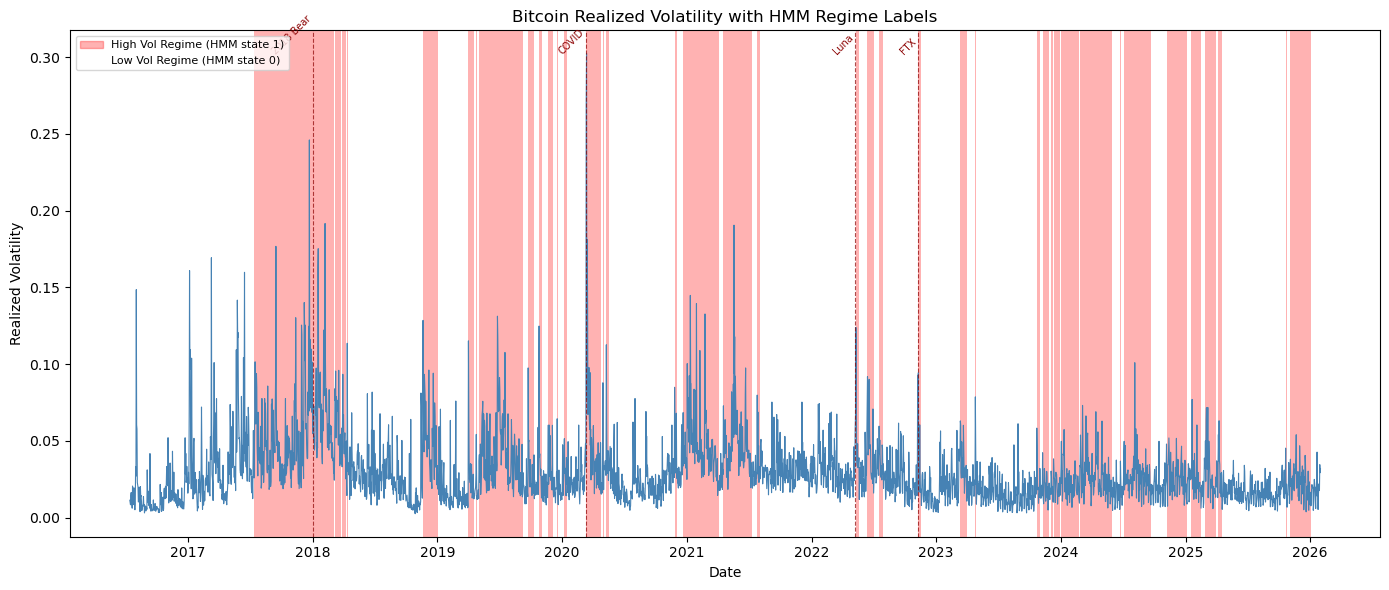

In [ ]:
from matplotlib import pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(1, 1, figsize=(14, 6))
plot_df = df_hmm[df_hmm["hmm_regime"] != -1].copy()

# Plot realized volatility
ax.plot(plot_df["date"], plot_df["realized_volatility"], color="steelblue", linewidth=0.8)
ax.set_ylabel("Realized Volatility")
ax.set_xlabel("Date")
ax.set_title("Bitcoin Realized Volatility with HMM Regime Labels")

# Shade high vol regime (state 1)
in_high_vol = False
start_date = None

for _, row in plot_df.iterrows():
    if row["hmm_regime"] == 1 and not in_high_vol:
        # entering high vol regime
        in_high_vol = True
        start_date = row["date"]
    elif row["hmm_regime"] == 0 and in_high_vol:
        # exiting high vol regime
        in_high_vol = False
        ax.axvspan(start_date, row["date"], alpha=0.3, color="red", linewidth=0)

# Handle case where series ends in high vol regime
if in_high_vol:
    ax.axvspan(start_date, plot_df["date"].iloc[-1], alpha=0.3, color="red", linewidth=0)

# Annotate known structural breaks
events = {
    "2018 Bear": "2018-01-01",
    "COVID":     "2020-03-12",
    "Luna":      "2022-05-09",
    "FTX":       "2022-11-08"
}
for label, date in events.items():
    ax.axvline(pd.Timestamp(date), color="darkred", linestyle="--", linewidth=0.8, alpha=0.7)
    ax.text(pd.Timestamp(date), ax.get_ylim()[1]*0.95, label, fontsize=7, color="darkred", rotation=45, ha='right')

high_patch = mpatches.Patch(color="red", alpha=0.3, label="High Vol Regime (HMM state 1)")
low_patch  = mpatches.Patch(color="white", edgecolor="grey", label="Low Vol Regime (HMM state 0)")
ax.legend(handles=[high_patch, low_patch], loc="upper left", fontsize=8)

plt.tight_layout()
plt.savefig("hmm_regimes_vol.png", dpi=150, bbox_inches="tight")
plt.show()